In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=pd.read_csv('data_science_job.csv')
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [16]:
data.isna().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [22]:
col=[var for var in data.columns if data[var].isna().mean()<0.05 and data[var].isna().mean()>0]
col

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [23]:
data.shape

(19158, 13)

In [33]:
len(data.dropna(subset=col))/data.shape[0]

0.8968577095730244

In [37]:
new_df = data[col].dropna()
data.shape, new_df.shape

((19158, 13), (17182, 5))

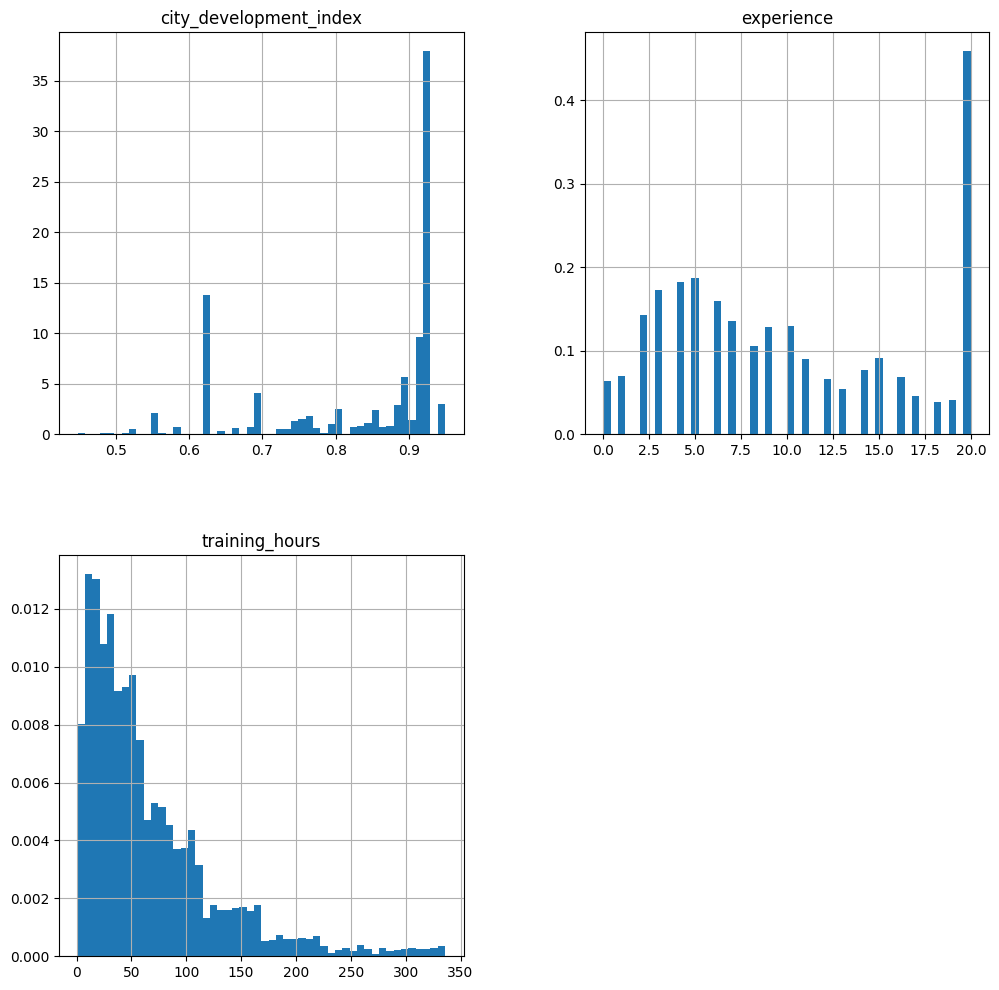

In [38]:
new_df.hist(bins=50, density=True, figsize=(12, 12))
plt.show()

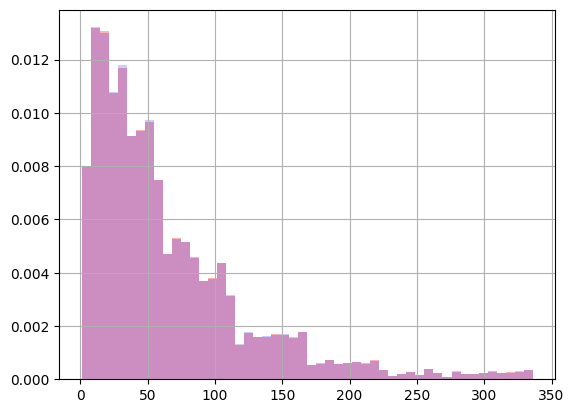

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['training_hours'].hist(bins=50, ax=ax, density=True, color='red',alpha=0.3)

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.2)
plt.show()

<Axes: ylabel='Density'>

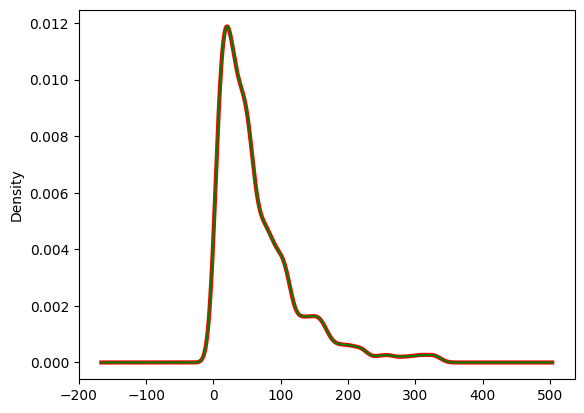

In [49]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['training_hours'].plot.density(color='red',linewidth=3)

# data after cca
new_df['training_hours'].plot.density(color='green')

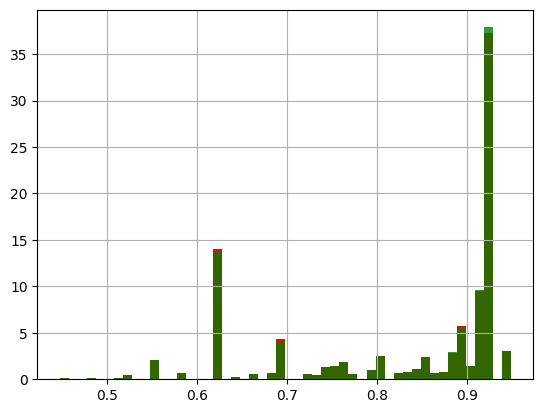

In [58]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)
plt.show()

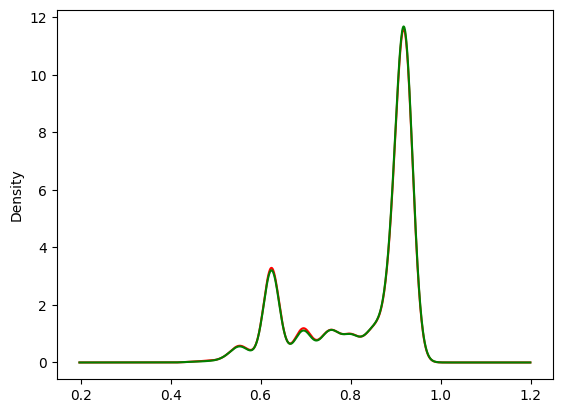

In [57]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')
plt.show()

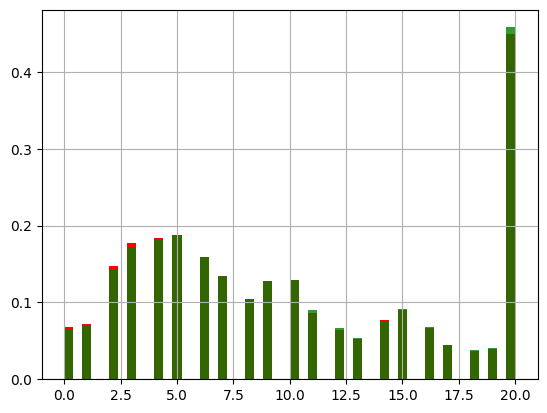

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)
plt.show()

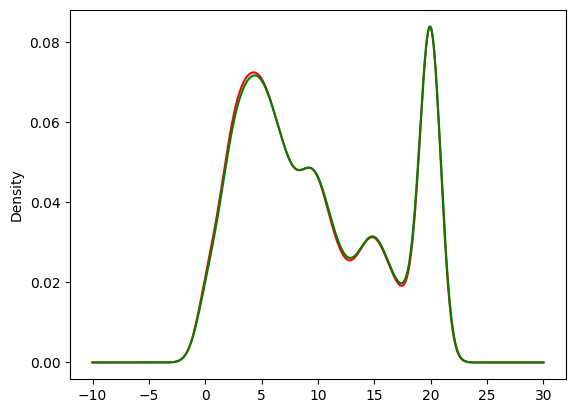

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
data['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')
plt.show()

In [60]:
temp = pd.concat([
            # percentage of observations per category, original data
            data['enrolled_university'].value_counts() / len(data),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [61]:
temp = pd.concat([
            # percentage of observations per category, original data
            data['education_level'].value_counts() / len(data),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


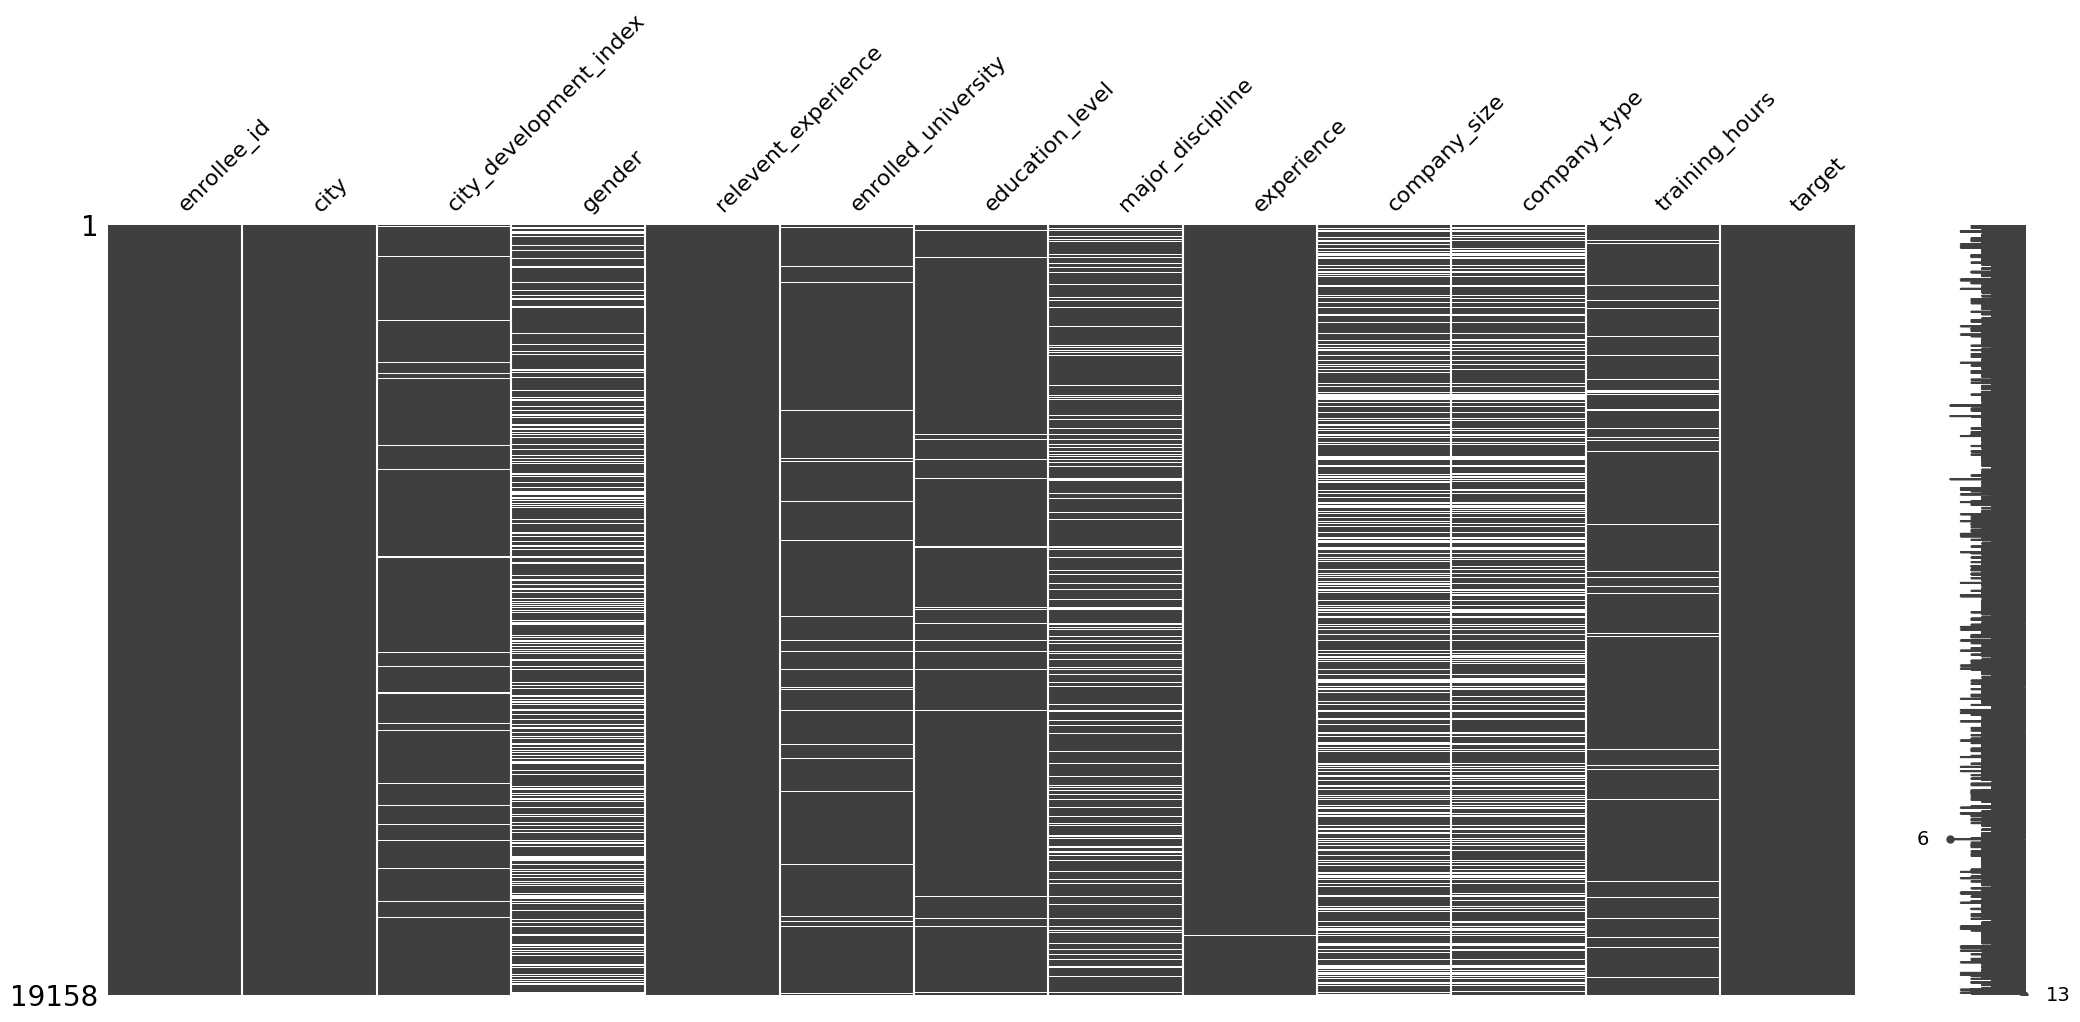

In [67]:
import missingno as msno
msno.matrix(data)
plt.show()